In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Known rows (last row's Profit is unknown -> prediction target)
data = pd.DataFrame({
    'Population': [10000, 15000, 20000, 9000],
    'YearsInBusiness': [5, 6, 6, 5],
    'Profit': [10000, 12000, 13000, 12000]
})
data

,Population,YearsInBusiness,Profit
0,10000,5,10000
1,15000,6,12000
2,20000,6,13000
3,9000,5,12000


In [ ]:
X_simple = data[['Population']]
y = data['Profit']

simple_model = LinearRegression()
simple_model.fit(X_simple, y)

print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"Coefficient (Population): {simple_model.coef_[0]:.6f}")

y_pred_simple = simple_model.predict(X_simple)

# Predict profit for the query row (Population = 12000)
query_pop = pd.DataFrame({'Population': [12000]})
pred_simple_query = simple_model.predict(query_pop)[0]
print(f"\nPredicted Profit for Population=12000: {pred_simple_query:.2f}")

Intercept: 9383.12
Coefficient (Population): 0.175325

Predicted Profit for Population=12000: 11487.01


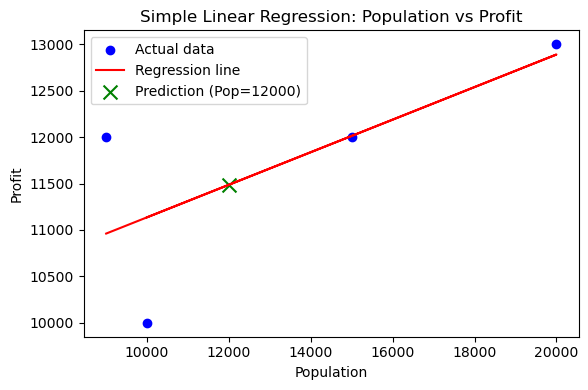

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(data['Population'], y, color='blue', label='Actual data')
plt.plot(data['Population'], y_pred_simple, color='red', label='Regression line')
plt.scatter([12000], [pred_simple_query], color='green', marker='x', s=100, label='Prediction (Pop=12000)')
plt.xlabel('Population')
plt.ylabel('Profit')
plt.title('Simple Linear Regression: Population vs Profit')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
mse_simple = mean_squared_error(y, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y, y_pred_simple)
r2_simple = r2_score(y, y_pred_simple)

print('Simple Linear Regression Performance (on training data):')
print(f'  MSE  : {mse_simple:.2f}')
print(f'  RMSE : {rmse_simple:.2f}')
print(f'  MAE  : {mae_simple:.2f}')
print(f'  R^2  : {r2_simple:.4f}')

Simple Linear Regression Performance (on training data):
  MSE  : 595779.22
  RMSE : 771.87
  MAE  : 574.68
  R^2  : 0.4983


In [ ]:
X_multi = data[['Population', 'YearsInBusiness']]

multi_model = LinearRegression()
multi_model.fit(X_multi, y)

print(f"Intercept: {multi_model.intercept_:.2f}")
print(f"Coefficients (Population, YearsInBusiness): {multi_model.coef_}")

y_pred_multi = multi_model.predict(X_multi)

# Predict profit for the query row (Population=12000, Years=4)
query_multi = pd.DataFrame({'Population': [12000], 'YearsInBusiness': [4]})
pred_multi_query = multi_model.predict(query_multi)[0]
print(f"\nPredicted Profit for Population=12000, Years=4: {pred_multi_query:.2f}")

Intercept: 7019.23
Coefficients (Population, YearsInBusiness): [1.15384615e-01 5.76923077e+02]

Predicted Profit for Population=12000, Years=4: 10711.54


In [ ]:
mse_multi = mean_squared_error(y, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y, y_pred_multi)
r2_multi = r2_score(y, y_pred_multi)

print('Multi-Linear Regression Performance (on training data):')
print(f'  MSE  : {mse_multi:.2f}')
print(f'  RMSE : {rmse_multi:.2f}')
print(f'  MAE  : {mae_multi:.2f}')
print(f'  R^2  : {r2_multi:.4f}')

Multi-Linear Regression Performance (on training data):
  MSE  : 581730.77
  RMSE : 762.71
  MAE  : 634.62
  R^2  : 0.5101


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression (Population)', 'Multi-Linear Regression (Population + Years)'],
    'MSE': [mse_simple, mse_multi],
    'RMSE': [rmse_simple, rmse_multi],
    'MAE': [mae_simple, mae_multi],
    'R2': [r2_simple, r2_multi],
    'Predicted Profit (Pop=12000, Years=4)': [pred_simple_query, pred_multi_query]
})
comparison

,Model,MSE,RMSE,MAE,R2,"Predicted Profit (Pop=12000, Years=4)"
0,Simple Linear Regression (Population),595779.220779,771.86736,574.675325,0.498291,11487.012987
1,Multi-Linear Regression (Population + Years),581730.769231,762.71277,634.615385,0.510121,10711.538462
